In [1]:
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
###
# Inspect difference of exp with DL spec and non DL spec

In [3]:
### dict of {description : (protein matrix path, precursor matrix path)} 
paths = {
    'exprimental library with MBR' : ('outputs/exp-lib-2/report.pg_matrix.tsv', 'outputs/exp-lib-2/report.pr_matrix.tsv'),
    'exprimental library' : ('outputs/exp-lib-rerun-2/report.pg_matrix.tsv', 'outputs/exp-lib-rerun-2/report.pr_matrix.tsv'),
    'predicted library without Ox' : ('outputs/pred-lib/pred-lib/report.pg_matrix.tsv', 'outputs/pred-lib/pred-lib/report.pr_matrix.tsv'),
    'predicted library with Ox' : ('outputs/pred-lib-ox/pred-lib/report.pg_matrix.tsv', 'outputs/pred-lib-ox/pred-lib/report.pr_matrix.tsv'),
    'trial setting' : ('outputs/search-diann22-250911-Huy-lib/report.pg_matrix.tsv', 'outputs/search-diann22-250911-Huy-lib/report.pr_matrix.tsv'),
    'merge library' : ('outputs/merge-lib/run/report.pg_matrix.tsv', 'outputs/merge-lib/run/report.pr_matrix.tsv'),
    'merge 2' : ('outputs/merge-2/analyze/report.pg_matrix.tsv', 'outputs/merge-2/analyze/report.pr_matrix.tsv'),
}

In [4]:
tables = {
    'exprimental library with MBR - protein' : pd.read_csv(paths['exprimental library with MBR'][0], sep='\t'),
    'exprimental library with MBR - precursor' : pd.read_csv(paths['exprimental library with MBR'][1], sep='\t'),
    'exprimental library - protein' : pd.read_csv(paths['exprimental library'][0], sep='\t'),
    'exprimental library - precursor' : pd.read_csv(paths['exprimental library'][1], sep='\t'),
    'predicted library without Ox - protein' : pd.read_csv(paths['predicted library without Ox'][0], sep='\t'),
    'predicted library without Ox - precursor' : pd.read_csv(paths['predicted library without Ox'][1], sep='\t'),
    'predicted library with Ox - protein' : pd.read_csv(paths['predicted library with Ox'][0], sep='\t'),
    'predicted library with Ox - precursor' : pd.read_csv(paths['predicted library with Ox'][1], sep='\t'),
    'trial setting - protein' : pd.read_csv(paths['trial setting'][0], sep='\t'),
    'trial setting - precursor' : pd.read_csv(paths['trial setting'][1], sep='\t'),
    'merge library - protein' : pd.read_csv(paths['trial setting'][0], sep='\t'),
    'merge library - precursor' : pd.read_csv(paths['merge library'][1], sep='\t'),
    'merge 2 - protein' : pd.read_csv(paths['merge 2'][0], sep='\t'),
    'merge 2 - precursor' : pd.read_csv(paths['merge 2'][1], sep='\t')
}

In [5]:
sets = {}
for k, v in tables.items():
    if 'protein' in k:
        sets[k] = set(v['Protein.Group'].tolist())
    elif 'precursor' in k:
        sets[k] = set(v['Stripped.Sequence'].tolist())

# Run

In [6]:
def get_venn_diagram_information(names):
    if ('protein' in names[0]) and ('protein' in names[1]):
        set_one = sets[names[0]]
        set_two = sets[names[1]]
    elif ('precursor' in names[0]) and ('precursor' in names[1]):
        set_one = sets[names[0]]
        set_two = sets[names[1]]
    else:
        raise Exception('Matrices should be of both protein or precursor')
    
    interception = set_one & set_two
    print(f'"{names[0]}" vs "{names[1]}"')
    print(f"Length of {names[0]}: {len(set_one)}")
    print(f"Length of {names[1]}: {len(set_two)}")
    print(f'Interception: {len(interception)}')
    print(f'Difference of "{names[0]}": {len(set_one - interception)}')
    print(f'Difference of "{names[1]}": {len(set_two - interception)}')

lists = ['exprimental library - precursor', 'trial setting - precursor']
get_venn_diagram_information(lists)

"exprimental library - precursor" vs "trial setting - precursor"
Length of exprimental library - precursor: 18625
Length of trial setting - precursor: 33159
Interception: 15094
Difference of "exprimental library - precursor": 3531
Difference of "trial setting - precursor": 18065


In [7]:
tables['trial setting - protein']

,Protein.Group,Protein.Names,Genes,First.Protein.Description,N.Sequences,N.Proteotypic.Sequences,R:\TP\EXP_plasma_DIA\raw6\TIM_3448_2024-11-11_S6-A1_241111_OPL3026_VLH_VA_plasma_01.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3451_2024-11-11_S6-A4_241111_OPL3026_VLH_VA_plasma_04.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3454_2024-11-11_S6-A7_241111_OPL3026_VLH_VA_plasma_07.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3458_2024-11-12_S6-B1_241111_OPL3026_VLH_VA_plasma_10.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3461_2024-11-12_S6-B4_241111_OPL3026_VLH_VA_plasma_13.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3464_2024-11-12_S6-B7_241111_OPL3026_VLH_VA_plasma_16.d
0,A0A075B6H7,KV37_HUMAN,IGKV3-7,Probable non-functional immunoglobulin kappa v...,3,2,1582780.0,1046160.00,1489150.00,288800.00,586959.00,263118.000
1,A0A075B6H9,LV469_HUMAN,IGLV4-69,Immunoglobulin lambda variable 4-69,3,3,330093.0,333627.00,215305.00,17599.90,29994.60,6385.410
2,A0A075B6I0,LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,2,2,10785.2,9846.69,8792.63,23907.40,26241.40,11725.400
3,A0A075B6I1,LV460_HUMAN,IGLV4-60,Immunoglobulin lambda variable 4-60,3,3,25104.8,32074.60,29017.70,4843.77,2900.14,1091.940
4,A0A075B6I4,LVX54_HUMAN,IGLV10-54,Immunoglobulin lambda variable 10-54,1,1,104504.0,16768.60,28289.60,11470.00,NaN,512.777
...,...,...,...,...,...,...,...,...,...,...,...,...
3575,Q9Y6R7,FCGBP_HUMAN,FCGBP,IgGFc-binding protein,62,62,83669.3,105130.00,82554.00,9760.50,18140.10,3955.460
3576,Q9Y6W5,WASF2_HUMAN,WASF2,Actin-binding protein WASF2,7,6,NaN,NaN,6420.78,15400.10,16265.50,21196.500
3577,Q9Y6X5,ENPP4_HUMAN,ENPP4,Bis(5'-adenosyl)-triphosphatase ENPP4,5,4,NaN,NaN,NaN,2948.06,2013.78,4095.050
3578,Q9Y6Y8,S23IP_HUMAN,SEC23IP,SEC23-interacting protein,6,6,NaN,NaN,NaN,4527.04,4005.90,3487.940


In [8]:
tb = tables['exprimental library - precursor']
qr = tb[tb['Stripped.Sequence'].isin(sets['exprimental library - precursor'] - sets['trial setting - precursor'])]
qr.query('`Stripped.Sequence`.str.contains("AEVE")')

,Protein.Group,Protein.Ids,Protein.Names,Genes,First.Protein.Description,Proteotypic,Stripped.Sequence,Modified.Sequence,Precursor.Charge,Precursor.Id,D:\DIANN-beg\data\TIM_3448_2024-11-11_S6-A1_241111_OPL3026_VLH_VA_plasma_01.d,D:\DIANN-beg\data\TIM_3451_2024-11-11_S6-A4_241111_OPL3026_VLH_VA_plasma_04.d,D:\DIANN-beg\data\TIM_3454_2024-11-11_S6-A7_241111_OPL3026_VLH_VA_plasma_07.d,D:\DIANN-beg\data\TIM_3458_2024-11-12_S6-B1_241111_OPL3026_VLH_VA_plasma_10.d,D:\DIANN-beg\data\TIM_3461_2024-11-12_S6-B4_241111_OPL3026_VLH_VA_plasma_13.d,D:\DIANN-beg\data\TIM_3464_2024-11-12_S6-B7_241111_OPL3026_VLH_VA_plasma_16.d
35,Q9NP97,Q8TF09;Q9NP97;Q9NP97-2,DLRB1_HUMAN,DYNLRB1,Dynein light chain roadblock-type 1,0,AEVEETLKR,(UniMod:1)AEVEETLKR,2,(UniMod:1)AEVEETLKR2,NaN,NaN,NaN,1980.81,NaN,11796.10
1589,P01023,P01023,A2MG_HUMAN,A2M,Alpha-2-macroglobulin,1,APVGHFYEPQAPSAEVEMTSYVLLAYLTAQPAPTSEDLTSATNIVK,APVGHFYEPQAPSAEVEMTSYVLLAYLTAQPAPTSEDLTSATNIVK,5,APVGHFYEPQAPSAEVEMTSYVLLAYLTAQPAPTSEDLTSATNIVK5,16423.40,29794.20,16672.1,NaN,1341.95,620.38
4060,P02768,P02768;P02768-2,ALBU_HUMAN,ALB,Albumin,1,ECCEKPLLEKSHCIAEVENDEMPADLPSLAADFVESK,EC(UniMod:4)C(UniMod:4)EKPLLEKSHC(UniMod:4)IAE...,4,EC(UniMod:4)C(UniMod:4)EKPLLEKSHC(UniMod:4)IAE...,2750.43,3947.89,3982.4,NaN,NaN,NaN
17612,P02768,P02768;P02768-2,ALBU_HUMAN,ALB,Albumin,1,SHCIAEVENDEMPADLPSLAADFVESKDVCKNYAEAK,SHC(UniMod:4)IAEVENDEMPADLPSLAADFVESKDVC(UniMo...,4,SHC(UniMod:4)IAEVENDEMPADLPSLAADFVESKDVC(UniMo...,NaN,NaN,NaN,NaN,3091.31,9433.41


In [9]:
tables['trial setting - precursor'].query("`Precursor.Id`.str.startswith('C')")

,Protein.Group,Protein.Ids,Protein.Names,Genes,First.Protein.Description,Proteotypic,Stripped.Sequence,Modified.Sequence,Precursor.Charge,Precursor.Id,R:\TP\EXP_plasma_DIA\raw6\TIM_3448_2024-11-11_S6-A1_241111_OPL3026_VLH_VA_plasma_01.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3451_2024-11-11_S6-A4_241111_OPL3026_VLH_VA_plasma_04.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3454_2024-11-11_S6-A7_241111_OPL3026_VLH_VA_plasma_07.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3458_2024-11-12_S6-B1_241111_OPL3026_VLH_VA_plasma_10.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3461_2024-11-12_S6-B4_241111_OPL3026_VLH_VA_plasma_13.d,R:\TP\EXP_plasma_DIA\raw6\TIM_3464_2024-11-12_S6-B7_241111_OPL3026_VLH_VA_plasma_16.d
3679,Q13098;Q13098-5;Q13098-7,Q13098;Q13098-5;Q13098-6;Q13098-7,CSN1_HUMAN,GPS1,COP9 signalosome complex subunit 1,1,CAAGLAELAAR,C(UniMod:4)AAGLAELAAR,2,C(UniMod:4)AAGLAELAAR2,NaN,NaN,NaN,2716.44,NaN,3207.340
3680,Q5H9R7;Q5H9R7-2;Q5H9R7-5;Q5H9R7-6,Q5H9R7;Q5H9R7-2;Q5H9R7-4;Q5H9R7-5;Q5H9R7-6,PP6R3_HUMAN,PPP6R3,Serine/threonine-protein phosphatase 6 regulat...,1,CAAPRPPSSSPEQR,C(UniMod:4)AAPRPPSSSPEQR,3,C(UniMod:4)AAPRPPSSSPEQR3,NaN,NaN,NaN,3737.67,2404.27,1857.220
3681,Q07954,Q07954,LRP1_HUMAN,LRP1,Prolow-density lipoprotein receptor-related pr...,1,CACPTNFYLGSDGR,C(UniMod:4)AC(UniMod:4)PTNFYLGSDGR,2,C(UniMod:4)AC(UniMod:4)PTNFYLGSDGR2,NaN,NaN,NaN,4644.84,4899.74,811.883
3682,P35555,P35555,FBN1_HUMAN,FBN1,Fibrillin-1,1,CACTYGFTGPQCER,C(UniMod:4)AC(UniMod:4)TYGFTGPQC(UniMod:4)ER,2,C(UniMod:4)AC(UniMod:4)TYGFTGPQC(UniMod:4)ER2,NaN,NaN,NaN,4763.82,8871.79,1270.430
3683,P26927,P26927,HGFL_HUMAN,MST1,Hepatocyte growth factor-like protein,1,CADDQPPSILDPPDQVQFEK,C(UniMod:4)ADDQPPSILDPPDQVQFEK,2,C(UniMod:4)ADDQPPSILDPPDQVQFEK2,45793.1,34537.5,18398.00,3449.68,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4384,P01591,P01591,IGJ_HUMAN,JCHAIN,Immunoglobulin J chain,1,CYTAVVPLVYGGETK,C(UniMod:4)YTAVVPLVYGGETK,2,C(UniMod:4)YTAVVPLVYGGETK2,3739340.0,3153220.0,1769670.00,303331.00,786399.00,118410.000
4385,P01591,P01591,IGJ_HUMAN,JCHAIN,Immunoglobulin J chain,1,CYTAVVPLVYGGETK,C(UniMod:4)YTAVVPLVYGGETK,3,C(UniMod:4)YTAVVPLVYGGETK3,54988.9,33530.7,27654.10,2618.54,5759.23,NaN
4386,P23229-2;P23229-4;P23229-6;P23229-9,P23229;P23229-2;P23229-4;P23229-6;P23229-3;P23...,ITA6_HUMAN,ITGA6,Isoform Alpha-6X1A of Integrin alpha-6,1,CYVLSQNLR,C(UniMod:4)YVLSQNLR,2,C(UniMod:4)YVLSQNLR2,NaN,NaN,1957.92,3578.79,3651.40,4708.260
4387,P48556,P48556,PSMD8_HUMAN,PSMD8,26S proteasome non-ATPase regulatory subunit 8,1,CYYFDYK,C(UniMod:4)YYFDYK,2,C(UniMod:4)YYFDYK2,NaN,NaN,NaN,1477.02,1668.47,976.654


In [10]:
tables['trial setting - precursor'];

In [11]:
# with open('uniprot_reviewed_human_canonical_and_isoforms_20230330.fasta', 'r') as file:
#     text = file.read()

# not_found_in_fasta_set_one = set()
# for sq in set(tables['exprimental library - precursor']['Stripped.Sequence'].tolist()):
#     if sq not in text:
#         not_found_in_fasta_set_one.add(sq)

# not_found_in_fasta_set_two = set()
# for sq in set(qr['Stripped.Sequence'].tolist()):
#     if sq not in text:
#         not_found_in_fasta_set_two.add(sq)

# not_found_in_fasta_set_one - not_found_in_fasta_set_two

# Library

In [12]:
TARGET_SEQ = 'AEVEETLKR'
SEQ_ID = '(UniMod:1)AEVEETLKR2'

In [13]:
fts = ['Precursor.Id', 'RT',
       'IM', 'Precursor.Mz', 'Product.Mz', 'Relative.Intensity', 'Q.Value',
       'Fragment.Type', 'Fragment.Charge', 'Fragment.Series.Number']

In [14]:
predlib = pd.read_parquet('outputs/search-diann22-250911-Huy-lib/report-lib.parquet')
predlib[predlib['Stripped.Sequence'].str.contains('YRL')];
# AAAAAGLGGGGAGPGPEAGDFLARYRLVSNK	

In [15]:
explib = pd.read_csv('TIM_240819_OPL1041_CdAM_JNL_Plasma_DDA_library_CUMULATIVE_library.tsv', sep='\t')

In [16]:
explib[
    (explib['PeptideSequence'].str.contains(TARGET_SEQ)) 
    # &(explib['FragmentType'] == 'b')
    # & (explib['PrecursorCharge'] == 3)
].sort_values(by='FragmentSeriesNumber')

,PrecursorMz,ProductMz,Annotation,ProteinId,GeneName,PeptideSequence,ModifiedPeptideSequence,PrecursorCharge,LibraryIntensity,NormalizedRetentionTime,PrecursorIonMobility,FragmentType,FragmentCharge,FragmentSeriesNumber,FragmentLossType,AverageExperimentalRetentionTime
245873,558.798406,243.097550,b2^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,668.01624,25.64765,0.931895,b,1,2,NaN,1112.185433
245874,558.798406,342.165964,b3^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,751.59130,25.64765,0.931895,b,1,3,NaN,1112.185433
245876,558.798406,416.297981,y3^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,917.03894,25.64765,0.931895,y,1,3,NaN,1112.185433
245879,558.798406,517.345660,y4^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,1890.34960,25.64765,0.931895,y,1,4,NaN,1112.185433
245880,558.798406,600.251153,b5^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,779.35223,25.64765,0.931895,b,1,5,NaN,1112.185433
245881,558.798406,646.388254,y5^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,4298.44530,25.64765,0.931895,y,1,5,NaN,1112.185433
245882,558.798406,775.430848,y6^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,10000.00000,25.64765,0.931895,y,1,6,NaN,1112.185433
245875,558.798406,388.219062,y6^2,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,1512.09670,25.64765,0.931895,y,2,6,NaN,1112.185433
245883,558.798406,874.499263,y7^1,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,3673.11740,25.64765,0.931895,y,1,7,NaN,1112.185433
245877,558.798406,437.753270,y7^2,Q9NP97,DYNLRB1,AEVEETLKR,(UniMod:1)AEVEETLKR,2,1212.46670,25.64765,0.931895,y,2,7,NaN,1112.185433


In [17]:
tmp1 = pq.read_table('outputs/trial-lib-to-parquet/report-lib.parquet', filters=[('Stripped.Sequence', '==', TARGET_SEQ)], columns=fts)

In [18]:
tmp2 = pq.read_table('outputs/hand-built-lib-to-parquet/report-lib.parquet')
tmp3 = pq.read_table('outputs/hand-built-lib-with-select/report-lib.parquet')
tmp4 = pq.read_table('outputs/exp-lib-rerun-2/report-lib.parquet')
tmp5 = pq.read_table('outputs/merge-lib/merge/report-lib.parquet')
tmp6 = pq.read_table('outputs/search-diann22-250911-Huy-lib/report-lib.parquet')

In [19]:
tb_tmp1 = tmp1.to_pandas()
tb_tmp2 = tmp2.to_pandas()
tb_tmp3 = tmp3.to_pandas()
tb_tmp4 = tmp4.to_pandas()
tb_tmp5 = tmp5.to_pandas()
tb_tmp6 = tmp6.to_pandas()

In [20]:
tb_tmp1

,Precursor.Id,RT,IM,Precursor.Mz,Product.Mz,Relative.Intensity,Q.Value,Fragment.Type,Fragment.Charge,Fragment.Series.Number
0,AEVEETLKR2,-23.537998,0.906143,537.793091,775.430847,1.000000,0.0,y,1,6
1,AEVEETLKR2,-23.537998,0.906143,537.793091,874.499268,0.956312,0.0,y,1,7
2,AEVEETLKR2,-23.537998,0.906143,537.793091,437.753265,0.831251,0.0,y,2,7
3,AEVEETLKR2,-23.537998,0.906143,537.793091,646.388245,0.566958,0.0,y,1,5
4,AEVEETLKR2,-23.537998,0.906143,537.793091,517.345642,0.273594,0.0,y,1,4
5,AEVEETLKR2,-23.537998,0.906143,537.793091,502.274567,0.209865,0.0,y,2,8
6,AEVEETLKR2,-23.537998,0.906143,537.793091,300.155396,0.172134,0.0,b,1,3
7,AEVEETLKR2,-23.537998,0.906143,537.793091,388.219055,0.138382,0.0,y,2,6
8,AEVEETLKR2,-23.537998,0.906143,537.793091,416.297974,0.072628,0.0,y,1,3
9,AEVEETLKR2,-23.537998,0.906143,537.793091,429.197998,0.045172,0.0,b,1,4


In [21]:
qr_tmp1 = tb_tmp1.loc[:, fts].query(
    '`Precursor.Id` == @SEQ_ID'
).sort_values(by='Fragment.Series.Number')
qr_tmp1

,Precursor.Id,RT,IM,Precursor.Mz,Product.Mz,Relative.Intensity,Q.Value,Fragment.Type,Fragment.Charge,Fragment.Series.Number
31,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,416.297974,0.109086,0.0,y,1,3
28,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,342.165955,0.280549,0.0,b,1,3
27,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,517.345642,0.355554,0.0,y,1,4
32,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,471.208557,0.079338,0.0,b,1,4
35,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,323.697754,0.039591,0.0,y,2,5
25,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,646.388245,0.569031,0.0,y,1,5
24,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,775.430847,1.000000,0.0,y,1,6
33,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,388.219055,0.056789,0.0,y,2,6
26,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,874.499268,0.537039,0.0,y,1,7
29,(UniMod:1)AEVEETLKR2,11.652107,0.92478,558.798401,437.753265,0.168453,0.0,y,2,7


In [22]:
qr_tmp2 = tb_tmp2[
    (tb_tmp2['Stripped.Sequence'] == TARGET_SEQ)
    # & (~tb_tmp2['Precursor.Id'].str.contains('35'))
    
    ].loc[:, fts].sort_values(by='Fragment.Series.Number')
qr_tmp2

,Precursor.Id,RT,IM,Precursor.Mz,Product.Mz,Relative.Intensity,Q.Value,Fragment.Type,Fragment.Charge,Fragment.Series.Number
1629,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,243.097549,0.066802,0.0,b,1,2
1626,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,416.297974,0.091704,0.0,y,1,3
1628,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,342.165955,0.075159,0.0,b,1,3
1621,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,517.345642,0.189035,0.0,y,1,4
1627,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,600.251160,0.077935,0.0,b,1,5
1619,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,646.388245,0.429845,0.0,y,1,5
1618,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,775.430847,1.000000,0.0,y,1,6
1623,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,388.219055,0.151210,0.0,y,2,6
1624,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,437.753265,0.121247,0.0,y,2,7
1620,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,874.499268,0.367312,0.0,y,1,7


In [23]:
qr_tmp3 = tb_tmp3[
    (tb_tmp3['Precursor.Id'] == SEQ_ID) 
    ].loc[:, fts].sort_values(by='Fragment.Series.Number')
qr_tmp3

,Precursor.Id,RT,IM,Precursor.Mz,Product.Mz,Relative.Intensity,Q.Value,Fragment.Type,Fragment.Charge,Fragment.Series.Number
1509,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,416.297974,0.091704,0.0,y,1,3
1504,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,517.345642,0.189035,0.0,y,1,4
1510,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,600.251160,0.077935,0.0,b,1,5
1502,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,646.388245,0.429845,0.0,y,1,5
1501,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,775.430847,1.000000,0.0,y,1,6
1506,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,388.219055,0.151210,0.0,y,2,6
1503,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,874.499268,0.367312,0.0,y,1,7
1507,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,437.753265,0.121247,0.0,y,2,7
1508,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,1003.541870,0.094284,0.0,y,1,8
1505,(UniMod:1)AEVEETLKR2,25.64765,0.931895,558.798401,502.274567,0.163917,0.0,y,2,8


In [24]:
def annote_fragment(row):
    return row['Fragment.Type'] + str(row['Fragment.Series.Number']) + '^' + str(row['Fragment.Charge'])

# qr_tmp3.apply(annote_fragment, axis=1) #test

In [25]:
def plot_fragment(precursor, mz, intensities, labels):
    # Select the 6 most significant fragments by sorting intensities descending
    indices = np.argsort(intensities)[::-1][:6]
    top_indices = set(indices)  # For quick lookup

    # Create the stick plot: different colors for top 6 (red) vs others (blue)
    plt.figure(figsize=(16, 4))
    colors = ['red' if i in top_indices else 'blue' for i in range(len(mz))]
    plt.vlines(mz, 0, intensities, colors=colors, linewidth=1.5)


    for i, (x, y, label) in enumerate(zip(mz, intensities, labels)):
        plt.text(x, y + 0.05, label, ha='center', va='bottom', fontsize=8, rotation=45)

    plt.xlabel('m/z')
    plt.ylabel('Relative Intensity')
    plt.title(precursor)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(0, 1.2)  # Add 10% headroom for y-axis
    plt.xlim(150, 1200)  # Add padding to x-axis

    plt.show()

In [26]:
def plot_fragment(query_1, query_2):

    def plot(precursor, mz, intensities, labels, xlims):
        # Select the 6 most significant fragments by sorting intensities descending
        indices = np.argsort(intensities)[::-1][:6]
        top_indices = set(indices)  # For quick lookup

        # Create the stick plot: different colors for top 6 (red) vs others (blue)
        plt.figure(figsize=(12, 3))
        colors = ['red' if i in top_indices else 'blue' for i in range(len(mz))]
        plt.bar(mz, intensities, color=colors, width=1.5)


        for i, (x, y, label) in enumerate(zip(mz, intensities, labels)):
            plt.text(x, y + 0.05, label, ha='center', va='bottom', fontsize=8, rotation=45)

        plt.xlabel('m/z')
        plt.ylabel('Relative Intensity')
        plt.title(precursor)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.ylim(0, 1.2)  # Add 10% headroom for y-axis
        plt.xlim(xlims[0] - 10, xlims[1] + 10)  # Add padding to x-axis

        plt.show()

    xlims = (np.min(query_1['Product.Mz'].tolist() + query_2['Product.Mz'].tolist()), np.max(query_1['Product.Mz'].tolist() + query_2['Product.Mz'].tolist()))
    plot(query_1['Precursor.Id'].iloc[0], query_1['Product.Mz'], query_1['Relative.Intensity'], query_1.apply(annote_fragment, axis=1), xlims)
    plot(query_2['Precursor.Id'].iloc[0], query_2['Product.Mz'], query_2['Relative.Intensity'], query_2.apply(annote_fragment, axis=1), xlims)

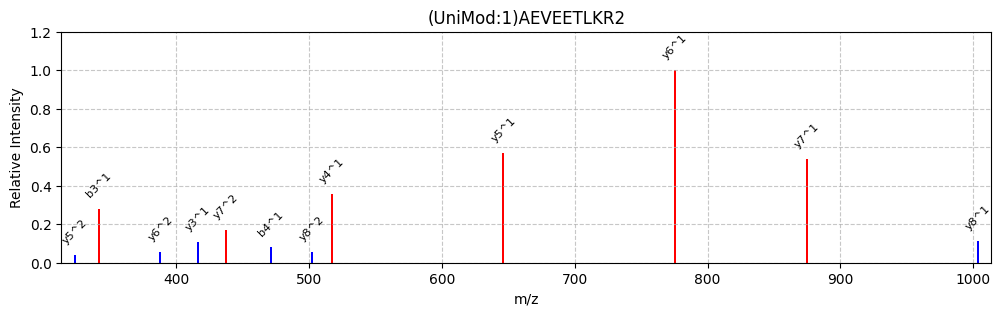

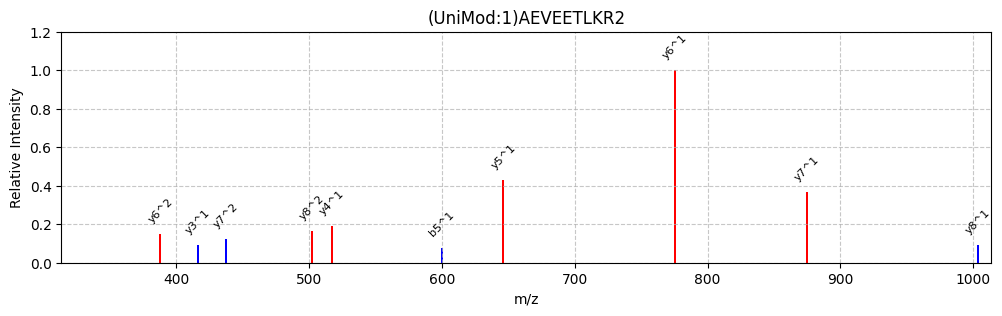

In [27]:
plot_fragment(qr_tmp1, qr_tmp3)

In [28]:
tb_tmp4[
    (tb_tmp4['Stripped.Sequence'] == TARGET_SEQ)
    & (tb_tmp4['Fragment.Type'] == 'b')
    ].loc[:, fts].sort_values(by='Fragment.Series.Number');

In [29]:
tb_tmp5.query('`Stripped.Sequence`.str.contains(@TARGET_SEQ)').loc[:, fts];

In [30]:
tb_tmp6.query('`Stripped.Sequence` == (@TARGET_SEQ)').loc[:, fts]

,Precursor.Id,RT,IM,Precursor.Mz,Product.Mz,Relative.Intensity,Q.Value,Fragment.Type,Fragment.Charge,Fragment.Series.Number


In [31]:
tb_tmp5.columns

Index(['Precursor.Id', 'Modified.Sequence', 'Stripped.Sequence',
       'Precursor.Charge', 'Proteotypic', 'Decoy', 'N.Term', 'C.Term', 'RT',
       'IM', 'Q.Value', 'Peptidoform.Q.Value', 'PTM.Site.Confidence',
       'PG.Q.Value', 'Precursor.Mz', 'Product.Mz', 'Relative.Intensity',
       'Fragment.Type', 'Fragment.Charge', 'Fragment.Series.Number',
       'Fragment.Loss.Type', 'Exclude.From.Quant', 'Protein.Ids',
       'Protein.Group', 'Protein.Names', 'Genes', 'Flags'],
      dtype='object')

In [32]:
pq.read_table('outputs/pred-lib-ox/emp-lib/report-lib.parquet').to_pandas().query('`Stripped.Sequence` == (@TARGET_SEQ)').loc[:, fts]

,Precursor.Id,RT,IM,Precursor.Mz,Product.Mz,Relative.Intensity,Q.Value,Fragment.Type,Fragment.Charge,Fragment.Series.Number


# Result

In [33]:
RES_FILTER_SQ = 'AAAAAAGAGPEMVR'

In [34]:
result_columns = ['Modified.Sequence', 'RT', 'Predicted.RT', 'iRT', 'Predicted.iRT']

In [35]:
predlib_result = pq.read_table('outputs/search-diann22-250911-Huy-lib/report.parquet').to_pandas()

In [36]:
explib_result = pq.read_table('outputs/exp-lib-rerun-2/report.parquet').to_pandas()

In [37]:
explib_result.query('`Stripped.Sequence` == @RES_FILTER_SQ').loc[:, result_columns];

In [38]:
predlib_result.query('`Stripped.Sequence` == @RES_FILTER_SQ').loc[:, result_columns];

In [39]:
print(predlib_result.columns.tolist())

['Run.Index', 'Run', 'Channel', 'Precursor.Id', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Charge', 'Precursor.Lib.Index', 'Decoy', 'Proteotypic', 'Precursor.Mz', 'Protein.Ids', 'Protein.Group', 'Protein.Names', 'Genes', 'RT', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'IM', 'iIM', 'Predicted.IM', 'Predicted.iIM', 'Precursor.Quantity', 'Precursor.Normalised', 'Ms1.Area', 'Ms1.Normalised', 'Ms1.Apex.Area', 'Ms1.Apex.Mz.Delta', 'Normalisation.Factor', 'Quantity.Quality', 'Empirical.Quality', 'Normalisation.Noise', 'Ms1.Profile.Corr', 'Evidence', 'Mass.Evidence', 'Channel.Evidence', 'Ms1.Total.Signal.Before', 'Ms1.Total.Signal.After', 'RT.Start', 'RT.Stop', 'FWHM', 'PG.TopN', 'PG.MaxLFQ', 'Genes.TopN', 'Genes.MaxLFQ', 'Genes.MaxLFQ.Unique', 'PG.MaxLFQ.Quality', 'Genes.MaxLFQ.Quality', 'Genes.MaxLFQ.Unique.Quality', 'Q.Value', 'PEP', 'Global.Q.Value', 'Lib.Q.Value', 'Peptidoform.Q.Value', 'Global.Peptidoform.Q.Value', 'Lib.Peptidoform.Q.Value', 'PTM.Site.Confidence', 'Site.Occupancy

# Plots

0.029586797788376314


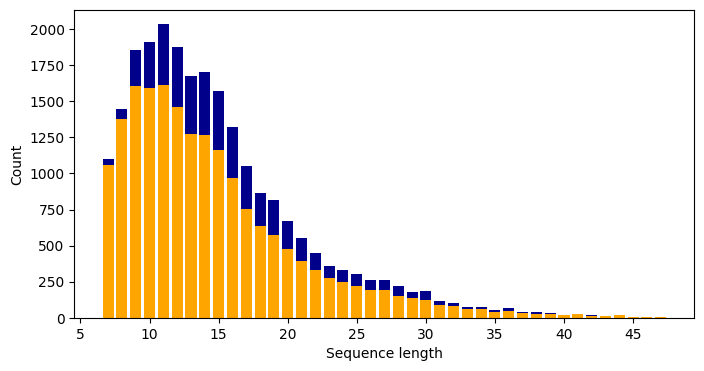

In [86]:
def plot_sequence_length(table):
    shortest_len = len(min(table['Stripped.Sequence'].tolist(), key=len))
    longest_len = len(max(table['Stripped.Sequence'].tolist(), key=len))
    unique_str = table['Stripped.Sequence'].unique()
    unique_str_length_counts = [0] * (longest_len - shortest_len + 1)
    for str in unique_str:
        unique_str_length_counts[len(str) - shortest_len] += 1
    length_counts = [len(table.query("`Stripped.Sequence`.str.len() == @length")['Stripped.Sequence']) for length in range(shortest_len, longest_len + 1)]
    
    plt.figure(figsize=(8, 4))
    plt.bar(range(shortest_len, longest_len + 1), length_counts, color='darkblue')
    plt.bar(range(shortest_len, longest_len + 1), unique_str_length_counts, color='orange')
    plt.xlabel('Sequence length')
    plt.ylabel('Count')

    print(f'{sum(length_counts[31-7:])/sum(length_counts[:])}')
plot_sequence_length(tables['exprimental library - precursor'])


In [41]:
def plot_modification_category_num(table):
    categories = ['UniMod:1', 'UniMod:4', 'UniMod:35']
    unique_count = []
    count = []
    for c in categories:
        count.append(table.query("`Precursor.Id`.str.contains(@c)").shape[0])
    for c in categories:
        compliment = categories.copy()
        compliment.remove(c)
        query = "`Precursor.Id`.str.contains(@c)"
        for other in compliment:
            query += (f" and ~`Precursor.Id`.str.contains('{other}')")
        unique_count.append(table.query(query).shape[0])
    
    plt.figure(figsize=(4, 4))
    plt.bar(categories, count, color='darkblue')
    plt.bar(categories, unique_count, color='orange')
    plt.ylabel('Count')

# plot_modification_category_num(tables['trial setting - precursor'])

In [42]:
def plot_var_modification_num(table):
    count = []
    QUERY = "(`Precursor.Id`.str.count('UniMod:1') + `Precursor.Id`.str.count('UniMod:35')) == "
    MAX_VAR_MOD = 3
    for i in range(1, MAX_VAR_MOD + 1):
        count.append(table.query(QUERY + f"{i}").shape[0])
    
    plt.figure(figsize=(4, 4))
    plt.bar(range(1, MAX_VAR_MOD + 1), count, color='skyblue')
    plt.xlabel('Number of variable modification')
    plt.ylabel('Count')
    plt.xticks(range(1, MAX_VAR_MOD + 1))

# plot_var_modification_num(tables['trial setting - precursor'])

In [43]:
def plot_precursor_charge(table):
    min_charge = min(table['Precursor.Charge'].tolist())
    max_charge = max(table['Precursor.Charge'].tolist())
    count = []
    for charge in range(min_charge, max_charge + 1):
        count.append(table.query(f"`Precursor.Charge` == {charge}").shape[0])
    
    plt.figure(figsize=(4, 4))
    plt.bar(range(min_charge, max_charge + 1), count, color='skyblue')
    plt.xlabel('Precursor charge')
    plt.ylabel('Count')
    plt.xticks(range(min_charge, max_charge + 1))
        
# plot_precursor_charge(tables['trial setting - precursor'])


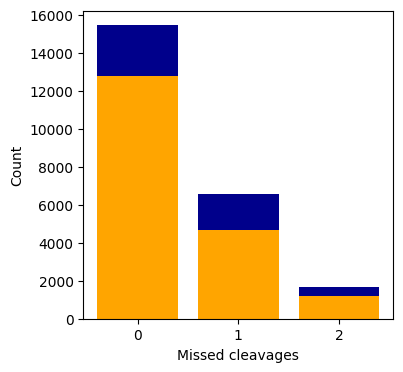

In [44]:
def plot_misscleavage(table):
    MAX_MISSCLEAVAGE = 2
    count = []
    QUERY = "(`Stripped.Sequence`.str.count('K')) + (`Stripped.Sequence`.str.count('R')) =="
    unique_str = table['Stripped.Sequence'].unique()
    unique_count = [0] * (MAX_MISSCLEAVAGE + 1)
    for str in unique_str:
        idx = str.count('K') + str.count('R')
        unique_count[max(idx - 1, 0)] += 1

    for i in range (0, MAX_MISSCLEAVAGE + 1):
        count.append(table.query(QUERY + f"{i + 1}").shape[0])
        if i == 0:
            count[0] += table.query(QUERY + f"{0}").shape[0]
    
    plt.figure(figsize=(4, 4))
    plt.bar(range(0, MAX_MISSCLEAVAGE + 1), count, color='darkblue')
    plt.bar(range(0, MAX_MISSCLEAVAGE + 1), unique_count, color='orange')
    plt.xlabel('Missed cleavages')
    plt.ylabel('Count')
    plt.xticks(range(0, MAX_MISSCLEAVAGE + 1))

plot_misscleavage(tables['exprimental library - precursor'])
